# Архитектура подготовки пространственных данных

Для решения задачи радиопланирования (3D-моделирования препятствий) мы разработали многоступенчатый пайплайн обработки геоданных. Главная цель: объединить детализированную фрагментированную геометрию из Источника А с достоверными высотными данными из кадастрового Источника Б, полностью исключив проблему **Target Leakage** (ошибочного присвоения высоты небоскребов одноэтажным пристройкам).

## Фаза 1: Внутридатасетная консолидация 
* **Проблема:** Наличие "геометрического мусора" (отдельно отрисованных крылец, трансформаторных будок, стилобатов), который мешает кросс-мэтчингу между базами.
* **Решение:** Вычисление 10-го перцентиля площади зданий. Пространственное слияние (Spatial Join + Dissolve) мелких объектов с ближайшими крупными зданиями в радиусе 3 метров.
* **Итог:** Сформированы идеальные базовые слои, очищенные от микро-шума.

## Фaза 2: Теневой Мэтчинг и Графы
* **Проблема:** Несоответствие границ полигонов между источниками (сдвиги координат спутников, разная методология отрисовки).
* **Решение:**
    1. Расчет точной пространственной метрики **Intersection over Union (IoU)** в метрической проекции (EPSG:32636).
    2. Применение консервативного порога **IoU >= 0.20** (выбрано на основе "метода локтя") для исключения ложных срабатываний.
    3. Применение теории графов (**NetworkX**) для поиска компонент связности. Всем пересекающимся объектам присвоен единый кластер (`complex_id`).
* **Итог:** Создан `MASTER_MONOLITH` — теневой слой слитых пятен застройки, агрегирующий общую максимальную высоту каждого комплекса.

## Фаза 3: Умное распределение высот (Алгоритм "Alpha/Beta")
* **Проблема:** Если скопировать общую высоту монолита на все его фрагменты, 1-этажный магазин получит высоту 10-этажной башни, что критически исказит радиопланирование.
* **Решение:** Возврат к исходной фрагментированной геометрии и векторизованное распределение таргета (`target_height`):
    1. **Альфа-здания:** Внутри каждого `complex_id` фрагмент с максимальной площадью признается основным (Альфа) и забирает полную кадастровую высоту комплекса.
    2. **Бета-здания (Пристройки):** Чтобы не обучать модель на синтетическом шуме, пристройки (Беты) жестко переводятся в NaN. Их честную высоту предскажет ML-модель на основе их реальной геометрии.
* **Итог:** Физически корректная разметка. ML-модель будет обучаться исключительно на достоверных данных.

## Фаза 4: Сборка и NLP-стандартизация признаков (Priority Keyword Mapping)
* **Проблема 1:** Потеря зданий из Источника Б, которые не имели пары в Источнике А.
* **Решение 1:** Выделение "сирот" через анти-джойн и вертикальная конкатенация с основной таблицей для максимального обогащения тренировочной выборки.
* **Проблема 2 (Взрыв размерности):** Категории в Источнике А представлены грязными строковыми массивами (например, `"['Жилое здание', 'Комплекс']"`), что неприемлемо для алгоритмов градиентного бустинга.
* **Решение 2 (NLP-пайплайн):**
    1. Безопасный парсинг списков через `ast.literal_eval`.
    2. Очистка от спецсимволов и приведение к нижнему регистру.
    3. Ранжирование мульти-тегов по экспертному **словарю приоритетов** (например, тег "Промышленность" имеет бóльший вес для радиопланирования, чем "Вспомогательная постройка").
* **Итог:** Хаотичные текстовые мутации сведены к ограниченному набору чистых доменных категорий. Сформирован итоговый `FINAL_ML_DATASET.csv`, далее в него будут добавлены фичи и перерассчет геометрии, после производится обучение модели 

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import warnings
import networkx as nx
import ast
warnings.filterwarnings('ignore')
from shapely.validation import make_valid
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")

Проанализируем перцентили площадей

In [4]:
percentiles_to_check = [0.01, 0.03, 0.05, 0.10, 0.15]

for src, file, geom_col in [("ИСТОЧНИК А", 'data/raw/cup_it_example_src_A.csv', 'geometry'), 
                            ("ИСТОЧНИК Б", 'data/raw/cup_it_example_src_B.csv', 'wkt')]:
    
    df_temp = pd.read_csv(file, usecols=[geom_col])
    gdf_temp = gpd.GeoDataFrame(df_temp, geometry=gpd.GeoSeries.from_wkt(df_temp[geom_col]), crs="EPSG:4326")
    
    areas = gdf_temp.to_crs(epsg=32636).geometry.area
    
    print(f"\n{src}:")
    for p in percentiles_to_check:
        val = areas.quantile(p)
        print(f"  {int(p*100)}-й перцентиль: отсекает всё, что меньше {val:.1f} кв.м")


ИСТОЧНИК А:
  1-й перцентиль: отсекает всё, что меньше 3.7 кв.м
  3-й перцентиль: отсекает всё, что меньше 7.5 кв.м
  5-й перцентиль: отсекает всё, что меньше 11.2 кв.м
  10-й перцентиль: отсекает всё, что меньше 19.3 кв.м
  15-й перцентиль: отсекает всё, что меньше 26.2 кв.м

ИСТОЧНИК Б:
  1-й перцентиль: отсекает всё, что меньше 12.4 кв.м
  3-й перцентиль: отсекает всё, что меньше 16.5 кв.м
  5-й перцентиль: отсекает всё, что меньше 19.3 кв.м
  10-й перцентиль: отсекает всё, что меньше 25.1 кв.м
  15-й перцентиль: отсекает всё, что меньше 30.3 кв.м


In [5]:
# настройки
PERCENTILE_THRESHOLD = 0.10 # 10-й перцентиль
BUFFER_SIZE = 2.5 # Буфер в метрах

# Черный список: сносим сразу 
BAD_KEYWORDS = ['гараж', 'туалет', 'трансформатор', 'беседка', 'сарай', 'навес', 
                'теплица', 'будка', 'паркинг', 'тп', 'руина', 'хоз', 'баня', 'котельн', 'забор', 'мусор']

# Белый список: не трогаем
GOOD_KEYWORDS = [
    'жило', 'промышлен', 'торгов', 'бизнес', 'образован', 'культур', 'детск', 
    'медицин', 'школ', 'религ', 'государств', 'спорт', 'офис', 'центр', 'церк', 
    'станци', 'больниц', 'авто', 'стадион', 'администрат', 'администраци', 
    'кафе', 'ресторан', 'гостиниц', 'хостел', 'бассейн', 'фастфуд', 'порт', 
    'вокзал', 'книжн', 'производствен', 'учебн', 'здравоохранен'
]

def clean_dataset_dynamic(df, geometry_col, text_col, dataset_name):
    
    # 1. Загрузка геометрии
    df['geometry'] = gpd.GeoSeries.from_wkt(df[geometry_col])
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
    initial_len = len(gdf)
    
    # 2. NLP чистка 
    def has_bad_tag(text):
        if pd.isna(text) or text == '[]': return False
        return any(kw in str(text).lower() for kw in BAD_KEYWORDS)

    mask_bad = gdf[text_col].apply(has_bad_tag)
    deleted_by_nlp = gdf[mask_bad]
    
    print(f"[{dataset_name}] Удалено по Черному списку: {mask_bad.sum()} объектов")
    if mask_bad.sum() > 0:
        print("Топ тегов удаленного жесткого мусора:")
        print(deleted_by_nlp[text_col].value_counts().head(5).to_string(header=False))
    
    gdf_clean_nlp = gdf[~mask_bad].copy()
    
    # 3. Динамический пространственный фильтр
    gdf_metric = gdf_clean_nlp.to_crs(epsg=32636)
    gdf_metric['geometry'] = gdf_metric['geometry'].apply(lambda g: make_valid(g) if not g.is_valid else g)
    gdf_metric['area_sqm'] = gdf_metric.geometry.area
    
    dyn_threshold = gdf_metric['area_sqm'].quantile(PERCENTILE_THRESHOLD)
    print(f"\n[{dataset_name}] Динамический порог ({(PERCENTILE_THRESHOLD*100):.0f}-й перцентиль): {dyn_threshold:.1f} кв.м")
    
    # Проверка на белый список 
    def has_good_tag(text):
        if pd.isna(text) or text == '[]': return False
        return any(kw in str(text).lower() for kw in GOOD_KEYWORDS)
        
    mask_good = gdf_metric[text_col].apply(has_good_tag)
    mask_large = gdf_metric['area_sqm'] > dyn_threshold
    
    # Основы - большие объекты или мелкие с иммунитетом
    bases = gdf_metric[mask_large | mask_good].copy()
    
    # Кандидаты - мелкие объекты без иммунитета ("дачные строения", "постройка, сооружение" и тд)
    candidates = gdf_metric[~mask_large & ~mask_good].copy()
    
    print(f"[{dataset_name}] Выделено основ: {len(bases)}")
    print(f"[{dataset_name}] Выделено кандидатов - потенциальный мусор: {len(candidates)}")
    
    # Буфер вокруг Основ
    bases_buffer = bases.copy()
    bases_buffer['geometry'] = bases_buffer.geometry.buffer(BUFFER_SIZE)
    
    # Спасаем тех кандидатов, кто коснулся буфера Основ
    saved_candidates = gpd.sjoin(candidates, bases_buffer[['id' if 'id' in bases.columns else bases.index.name or 'index', 'geometry']], 
                                 how='inner', predicate='intersects')
    saved_candidates = saved_candidates[~saved_candidates.index.duplicated(keep='first')]
    
    # Изолированный шум (Кандидаты - Спасенные)
    isolated_noise_indices = candidates.index.difference(saved_candidates.index)
    isolated_noise = candidates.loc[isolated_noise_indices]
    
    print(f"\n[{dataset_name}] Убрано изолированного шума: {len(isolated_noise)}")
    if len(isolated_noise) > 0:
        print("Теги удаленного изолированного шума:")
        print(isolated_noise[text_col].value_counts().head(10).to_string(header=False))
    
    # Склеиваем Основы и Спасенные пристройки обратно
    cols_to_drop = [c for c in saved_candidates.columns if c.endswith('_right') or c == 'index_right']
    saved_candidates = saved_candidates.drop(columns=cols_to_drop, errors='ignore')
    
    gdf_preprocessed_metric = pd.concat([bases, saved_candidates])
    gdf_preprocessed = gdf_preprocessed_metric.to_crs(epsg=4326)
    
    final_len = len(gdf_preprocessed)
    print(f"\n[{dataset_name}] Итого: Было {initial_len} -> Стало {final_len} (Удалено всего {initial_len - final_len})")
    
    return gdf_preprocessed


df_A_raw = pd.read_csv('data/raw/cup_it_example_src_A.csv')
gdf_A_clean = clean_dataset_dynamic(df_A_raw, geometry_col='geometry', text_col='tags', dataset_name="ИСТОЧНИК А")

df_B_raw = pd.read_csv('data/raw/cup_it_example_src_B.csv')
gdf_B_clean = clean_dataset_dynamic(df_B_raw, geometry_col='wkt', text_col='purpose_of_building', dataset_name="ИСТОЧНИК Б")


gdf_A_clean.drop(columns=['area_sqm'], errors='ignore').to_csv('data/processed/cup_it_src_A_CLEANED.csv', index=False)
gdf_B_clean.drop(columns=['area_sqm', 'wkt'], errors='ignore').to_csv('data/processed/cup_it_src_B_CLEANED.csv', index=False)
print("\nФайлы сохранены: 'data/processed/cup_it_src_A_CLEANED.csv' и 'data/processed/cup_it_src_B_CLEANED.csv'")

[ИСТОЧНИК А] Удалено по Черному списку: 345 объектов
Топ тегов удаленного жесткого мусора:
['мусорная площадка', 'постройка, сооружение']      203
['туалет', 'постройка, сооружение']                  61
['беседка', 'постройка, сооружение']                 40
['гаражный кооператив', 'постройка, сооружение']     13
['туалет', 'бизнес и услуги']                        12

[ИСТОЧНИК А] Динамический порог (10-й перцентиль): 19.4 кв.м
[ИСТОЧНИК А] Выделено основ: 161723
[ИСТОЧНИК А] Выделено кандидатов - потенциальный мусор: 9386

[ИСТОЧНИК А] Убрано изолированного шума: 6256
Теги удаленного изолированного шума:
['постройка, сооружение']                               6167
['Комплекс зданий', 'постройка, сооружение']              42
['службы и объекты ЖКХ', 'постройка, сооружение']         26
[None, 'постройка, сооружение']                            8
['вольер для птиц', 'постройка, сооружение']               8
['велопарковка', 'постройка, сооружение']                  2
['Парковка', 'постро

C:\Users\User\AppData\Local\Temp\ipykernel_3076\3012531228.py:99: DtypeWarning: Columns (0: fraction) have mixed types. Specify dtype option on import or set low_memory=False.
  df_B_raw = pd.read_csv('data/raw/cup_it_example_src_B.csv')


[ИСТОЧНИК Б] Удалено по Черному списку: 0 объектов

[ИСТОЧНИК Б] Динамический порог (10-й перцентиль): 25.1 кв.м
[ИСТОЧНИК Б] Выделено основ: 153707
[ИСТОЧНИК Б] Выделено кандидатов - потенциальный мусор: 7369

[ИСТОЧНИК Б] Убрано изолированного шума: 6499
Теги удаленного изолированного шума:
Строение дачное    6493

[ИСТОЧНИК Б] Итого: Было 161076 -> Стало 154577 (Удалено всего 6499)

Файлы сохранены: 'data/processed/cup_it_src_A_CLEANED.csv' и 'data/processed/cup_it_src_B_CLEANED.csv'


### Внутридатасетное разрешение сущностей 

Перед сопоставлением Источников А и Б необходимо устранить внутреннюю фрагментацию данных. В ГИС-системах сложные здания часто отрисовываются в виде набора раздельных полигонов (основное здание + примыкающие крыльца, стилобат, трансформаторные подстанции). 

Если не объединить их до расчета метрики Жаккара (IoU), площади совпадений будут искажены, что приведет к занижению метрики и потере связей.

**Алгоритм адаптивной сборки:**
1. **Разделение по перцентилю:** Вычисляется 10-й квантиль (перцентиль) распределения площадей внутри датасета. Объекты ниже этого порога классифицируются как "пристройки", выше — как "основа".
2. **Пространственная привязка:** Пристройки "примагничиваются" к ближайшему основному зданию в радиусе 3 метров. Одинокие микро-объекты (геометрический мусор, не имеющий "хозяина") отсекаются.
3. **Пространственное слияние:** Геометрия основы и пристроек сплавляется в единый монолитный полигон с сохранением всех атрибутов.

In [14]:
df_A = pd.read_csv('data/processed/cup_it_src_A_CLEANED.csv')
df_B = pd.read_csv('data/processed/cup_it_src_B_CLEANED.csv')

# вытягиваем stairs 
raw_B = pd.read_csv('data/raw/cup_it_example_src_B.csv', low_memory=False) 
df_stairs = raw_B[['id', 'stairs']].drop_duplicates(subset=['id'])

df_B = df_B.drop(columns=['stairs'], errors='ignore')

df_B = df_B.merge(df_stairs, on='id', how='left')
print("Этажи возвращены")


gdf_A = gpd.GeoDataFrame(df_A, geometry=gpd.GeoSeries.from_wkt(df_A['geometry']), crs="EPSG:4326")
gdf_B = gpd.GeoDataFrame(df_B, geometry=gpd.GeoSeries.from_wkt(df_B['geometry']), crs="EPSG:4326")

def merge_internal_parts(gdf, source_name, max_dist=3.0):
    
    # Переводим в метры для точного расчета площади и расстояний
    gdf_metric = gdf.to_crs(epsg=32636).copy()
    gdf_metric['temp_id'] = range(len(gdf_metric))
    gdf_metric['final_area_sqm'] = gdf_metric.geometry.area
    
    # Вычисляем 10-й перцентиль
    area_threshold = gdf_metric['final_area_sqm'].quantile(0.10)
    print(f"Динамический порог (10-й перцентиль): {area_threshold:.1f} кв.м.")
    
    # Разделяем на основу и мелочь
    large = gdf_metric[gdf_metric['final_area_sqm'] >= area_threshold].copy()
    small = gdf_metric[gdf_metric['final_area_sqm'] < area_threshold].copy()
    print(f"Основных зданий: {len(large)} | Пристроек/мусора: {len(small)}")
    
    # Присоединяем пристройки к основе
    attached_small = gpd.sjoin_nearest(
        small, 
        large[['temp_id', 'geometry']], 
        how='inner', 
        max_distance=max_dist,
        distance_col='dist_to_main'
    )
    
    # Убираем дубликаты строго по индексу, если прилипло к двум домам - берем ближайший
    attached_small = attached_small.sort_values('dist_to_main')
    attached_small = attached_small[~attached_small.index.duplicated(keep='first')]
    
    print(f"Успешно примагничено: {len(attached_small)}")
    print(f"Снесено геометрического мусора - сироты: {len(small) - len(attached_small)}")
    
    attached_small['temp_id'] = attached_small['temp_id_right']
    attached_small = attached_small[large.columns] 
    
    # Склеиваем и диссолвим
    combined = pd.concat([large, attached_small], ignore_index=True)
    
    # Правило для текстов
    def join_texts(series):
        vals = series.dropna().astype(str).unique()
        return ' | '.join(vals) if len(vals) > 0 else np.nan

    agg_rules = {}
    for col in combined.columns:
        if col not in ['temp_id', 'geometry', 'final_area_sqm']:
            # Если число - берем максимум (спасаем этажи)
            if pd.api.types.is_numeric_dtype(combined[col]):
                agg_rules[col] = 'max'
            # Если текст - склеиваем уникальные (спасаем теги)
            else:
                agg_rules[col] = join_texts
                
    # Выполняем расплавку полигонов
    final_gdf_metric = combined.dissolve(by='temp_id', aggfunc=agg_rules).reset_index()
    
    # Финализация
    final_gdf_metric['final_area_sqm'] = final_gdf_metric.geometry.area
    final_gdf = final_gdf_metric.to_crs(epsg=4326) # Возвращаем GPS координаты
    final_gdf = final_gdf.drop(columns=['temp_id', 'final_area_sqm'])
    
    print(f"Итог {source_name}: было {len(gdf)} фрагментов -> стало {len(final_gdf)} монолитных зданий.")
    return final_gdf

# Прогоняем обе базы через внутреннюю сборку
gdf_A_perfect = merge_internal_parts(gdf_A, "A")
gdf_B_perfect = merge_internal_parts(gdf_B, "B")

# Перезаписываем очищенные файлы версиями
gdf_A_perfect.to_csv('data/processed/cup_it_src_A_PERFECT.csv', index=False)
gdf_B_perfect.to_csv('data/processed/cup_it_src_B_PERFECT.csv', index=False)

Этажи возвращены
Динамический порог (10-й перцентиль): 24.2 кв.м.
Основных зданий: 148367 | Пристроек/мусора: 16486
Успешно примагничено: 11742
Снесено геометрического мусора - сироты: 4744
Итог A: было 164853 фрагментов -> стало 148367 монолитных зданий.
Динамический порог (10-й перцентиль): 28.8 кв.м.
Основных зданий: 139119 | Пристроек/мусора: 15458
Успешно примагничено: 9659
Снесено геометрического мусора - сироты: 5799
Итог B: было 154577 фрагментов -> стало 139119 монолитных зданий.


## Выбираем метрику Жаккара

Мы проводим пространственное пересечение обновленных датасетов и применим **Метод Локтя** для поиска оптимального порога отсечения шума. Благодаря предварительной консолидации крылец и пристроек, средний уровень IoU для истинных совпадений возрастет, что сделает мэтчинг более уверенным.

Найдено потенциальных пар (касаний): 211883


,Порог IoU,Оставшиеся пары,Отсеяно (Мусор)
0,0.01,179688,32195
1,0.05,134149,45539
2,0.10,116087,18062
3,0.15,104459,11628
4,0.20,94950,9509
5,0.25,86540,8410
6,0.30,78517,8023
7,0.40,62901,15616
8,0.50,47357,15544


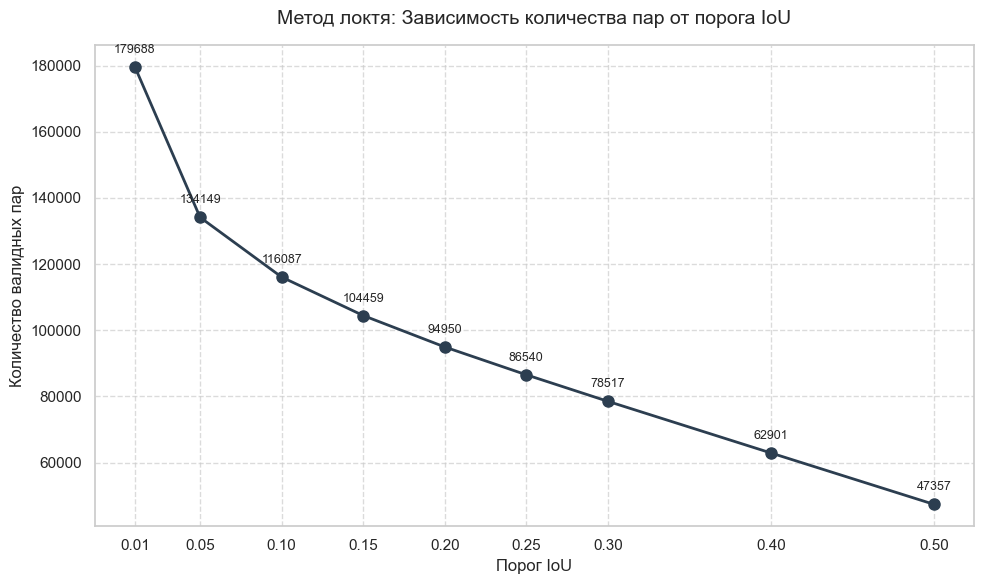

In [15]:
df_A = pd.read_csv('data/processed/cup_it_src_A_PERFECT.csv')
df_B = pd.read_csv('data/processed/cup_it_src_B_PERFECT.csv')

# Восстанавливаем геометрию
gdf_A = gpd.GeoDataFrame(df_A, geometry=gpd.GeoSeries.from_wkt(df_A['geometry']), crs="EPSG:4326")
gdf_B = gpd.GeoDataFrame(df_B, geometry=gpd.GeoSeries.from_wkt(df_B['geometry']), crs="EPSG:4326")

# Для точного расчета площадей переводим в метры
gdf_A_metric = gdf_A.to_crs(epsg=32636)
gdf_B_metric = gdf_B.to_crs(epsg=32636)

gdf_A_metric = gdf_A_metric[['id', 'geometry']].rename(columns={'id': 'id_A'})
gdf_B_metric = gdf_B_metric[['id', 'geometry']].rename(columns={'id': 'id_B'})

# Находим все пары, которые хоть немного касаются друг друга
overlaps = gpd.sjoin(gdf_A_metric, gdf_B_metric, how='inner', predicate='intersects')

print(f"Найдено потенциальных пар (касаний): {len(overlaps)}")

# Восстанавливаем геометрию Б для расчета пересечений
overlaps = overlaps.merge(gdf_B_metric[['id_B', 'geometry']], on='id_B', suffixes=('_A', '_B'))
overlaps = gpd.GeoDataFrame(overlaps, geometry='geometry_A', crs="EPSG:32636")
overlaps['geometry_B'] = gpd.GeoSeries(overlaps['geometry_B'], crs="EPSG:32636")

# Считаем Площадь Пересечения 
overlaps['intersect_area'] = overlaps['geometry_A'].intersection(overlaps['geometry_B']).area

# Считаем Площадь Объединения 
overlaps['union_area'] = overlaps['geometry_A'].union(overlaps['geometry_B']).area

# Вычисляем IoU (Жаккар)
overlaps['iou'] = overlaps['intersect_area'] / overlaps['union_area']

# метод локтя
thresholds = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
stats = []
previous_count = len(overlaps)

for t in thresholds:
    current_count = len(overlaps[overlaps['iou'] >= t])
    dropped = previous_count - current_count
    stats.append({
        'Порог IoU': t,
        'Оставшиеся пары': current_count,
        'Отсеяно (Мусор)': dropped
    })
    previous_count = current_count

iou_stats_df = pd.DataFrame(stats)
display(iou_stats_df)

# строим график
plt.figure(figsize=(10, 6))
plt.plot(iou_stats_df['Порог IoU'], iou_stats_df['Оставшиеся пары'], 
         marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=8)

plt.title('Метод локтя: Зависимость количества пар от порога IoU', fontsize=14, pad=15)
plt.xlabel('Порог IoU', fontsize=12)
plt.ylabel('Количество валидных пар', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(thresholds)

for i, row in iou_stats_df.iterrows():
    plt.annotate(int(row['Оставшиеся пары']), 
                 (row['Порог IoU'], row['Оставшиеся пары']), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

overlaps.drop(columns=['geometry_B', 'index_right'], errors='ignore').to_csv('data/processed/all_iou_pairs_perfect.csv', index=False)



### Обоснование выбора порога IoU = 0.20

Опираясь на график метода локтя и специфику наших пространственных данных, мы фиксируем порог пересечения на уровне **0.20**. 

**Почему именно 0.20:**
1. **Отсечение шума:** В диапазоне от 0.01 до 0.15 наблюдается самое резкое падение количества пар. Это отваливается пространственный "мусор" — соседние здания, которые случайно коснулись друг друга границами из-за погрешности отрисовки, или объекты, попавшие в чужой контур.
2. **Учет разницы в детализации источников:** Мы не можем ставить высокий порог (например, 0.5 и выше). Как было доказано на этапе EDA, Источник Б использует генерализованные контуры, а Источник А — высокодетальные полигоны с внутренними дворами. Из-за этой разницы идеального 100%-го совпадения площадей (IoU = 1.0) практически не бывает. Порог 0.20 гарантирует, что здания физически стоят на одном пятне застройки, но прощает неточности кадастровой отрисовки Источника Б.
3. **Сохранение объема выборки:** При пороге 0.20 мы сохраняем достаточное количество репрезентативных пар для уверенного обучения ML-модели, отбросив при этом заведомо ложные пересечения.

**Итог:** Все пересечения с IoU <= 0.20 признаются ложными и удаляются из итогового датасета.

### Графовая кластеризация и сборка "Теневого Монолита"

Объединяем разрозненные полигы из Источника А и Источника Б в единые архитектурные комплексы - монолиты. Этот слой данных необходим для того, чтобы корректно перенести целевую переменную (высоту) между базами.

**Пошаговый алгоритм работы:**

1. **Отсев шума:** Применяется жесткий фильтр `IoU >= 0.20`. Все пересечения с меньшей площадью отбрасываются как случайные касания или геометрический шум.
2. **Выделение компонент связности:** На основе подтвержденных пересечений строится неориентированный граф. Поиск связных подграфов (Connected Components) позволяет сгруппировать все пересекающиеся полигоны в единые кластеры (`complex_id`).
3. **Пространственное слияние:** Геометрия всех объектов внутри одного кластера объединяются в единый мультиполигон.
4. **Агрегация признаков:** При слиянии числовые атрибуты (высота, этажность) агрегируются по функции `max` для сохранения высотной доминанты, а категориальные и текстовые (теги) конкатенируются для сохранения семантики здания.

На выходе формируется `MASTER_BUILDINGS_DATASET`.

In [16]:
df_A = pd.read_csv('data/processed/cup_it_src_A_PERFECT.csv')
df_B = pd.read_csv('data/processed/cup_it_src_B_PERFECT.csv')
edges = pd.read_csv('data/processed/all_iou_pairs_perfect.csv')

# Превращаем в GeoDataFrame
gdf_A = gpd.GeoDataFrame(df_A, geometry=gpd.GeoSeries.from_wkt(df_A['geometry']), crs="EPSG:4326")
gdf_B = gpd.GeoDataFrame(df_B, geometry=gpd.GeoSeries.from_wkt(df_B['geometry']), crs="EPSG:4326")

# Восстанавливаем node_id чтобы различать источники в графе
gdf_A['node_id'] = 'A_' + gdf_A['id'].astype(str)
gdf_B['node_id'] = 'B_' + gdf_B['id'].astype(str)

valid_edges = edges[edges['iou'] >= 0.20].copy()
print(f"Осталось связей для Графа: {len(valid_edges)}")

# построение графа
G = nx.Graph()

# Добавляем все узлы
G.add_nodes_from(gdf_A['node_id'])
G.add_nodes_from(gdf_B['node_id'])

# Формируем ребра графа
valid_edges['node_A'] = 'A_' + valid_edges['id_A'].astype(str)
valid_edges['node_B'] = 'B_' + valid_edges['id_B'].astype(str)
G.add_edges_from(zip(valid_edges['node_A'], valid_edges['node_B']))

# Находим семьи зданий
components = list(nx.connected_components(G))
print(f"Итог графа: Найдено уникальных комплексов застроек (complex_id): {len(components)}")

# Раздаем complex_id каждому полигону
node_to_complex = {node: cid for cid, comp in enumerate(components) for node in comp}
gdf_A['complex_id'] = gdf_A['node_id'].map(node_to_complex)
gdf_B['complex_id'] = gdf_B['node_id'].map(node_to_complex)

# диссолвим данные перед теневым мержем
# Берем только то, что нужно для проброса высоты и аналитики
cols_A = ['complex_id', 'geometry', 'tags', 'gkh_floor_count_min', 'gkh_floor_count_max']
cols_B = ['complex_id', 'geometry', 'height', 'stairs', 'purpose_of_building', 'district', 'avg_floor_height']

cols_A = [c for c in cols_A if c in gdf_A.columns]
cols_B = [c for c in cols_B if c in gdf_B.columns]

# Конкатенируем
df_combined = pd.concat([gdf_A[cols_A], gdf_B[cols_B]], ignore_index=True)
gdf_combined = gpd.GeoDataFrame(df_combined, geometry='geometry', crs="EPSG:4326")

def join_texts(series):
    vals = series.dropna().astype(str).unique()
    return ' | '.join(vals) if len(vals) > 0 else np.nan

agg_rules = {}
for col in ['height', 'stairs', 'gkh_floor_count_max', 'gkh_floor_count_min', 'avg_floor_height']:
    if col in gdf_combined.columns: agg_rules[col] = 'max'
for col in ['tags', 'purpose_of_building', 'district']:
    if col in gdf_combined.columns: agg_rules[col] = join_texts

# Выполняем расплавку полигонов внутри complex_id
master_gdf = gdf_combined.dissolve(by='complex_id', aggfunc=agg_rules).reset_index()

print(f"Размер Теневого Монолита: {len(master_gdf)} уникальных зданий.")

master_gdf.to_csv('data/processed/MASTER_BUILDINGS_DATASET.csv', index=False)

Осталось связей для Графа: 94950
Итог графа: Найдено уникальных комплексов застроек (complex_id): 192598
Размер Теневого Монолита: 192598 уникальных зданий.


## Алгоритм "Alpha/Beta Height Distribution" (Векторизованный подход)

Для переноса высоты с Теневого Монолита на оригинальные фрагменты мы разработали векторизованный алгоритм "Альфа-Бета", который решает проблему перепадов высот (например, 10-этажная башня и 1-этажный стилобат по одному адресу).

**Логика алгоритма:**
1. **Representative point:** используем вместо центроидов, чтобы точка гарантировано попала в полигон, а не в пустоту
2. **Ранжирование по площади:** Фрагменты внутри одного `complex_id` сортируются по убыванию физической площади.
3. **Выделение "Альфы" - главное здание:** Фрагмент с максимальной площадью маркируется как Альфа-здание. Ему присваивается полная кадастровая высота комплекса.
4. **Обработка "Бет" - пристройка:** Меньшие фрагменты маркируются как Бета-здания. Для них применяется эвристика минимальной этажности:
   * Если в исходных данных есть `gkh_floor_count_min` ставим его в новый столбец floor_count.
   * Если данных о перепаде высот нет, Бета получает таргет `NaN`.
5. **Target Leakage Prevention:** Мы сознательно не заполняем пустые Беты средними или максимальными значениями. Эти объекты отправляются в тестовую выборку, где алгоритм градиентого бустинга предскажет их истинную высоту на основе паттернов из обучающей выборки.

In [17]:
df_A_raw = pd.read_csv('data/processed/cup_it_src_A_CLEANED.csv')
gdf_A = gpd.GeoDataFrame(df_A_raw, geometry=gpd.GeoSeries.from_wkt(df_A_raw['geometry']), crs="EPSG:4326")

df_master = pd.read_csv('data/processed/MASTER_BUILDINGS_DATASET.csv')
gdf_master = gpd.GeoDataFrame(df_master, geometry=gpd.GeoSeries.from_wkt(df_master['geometry']), crs="EPSG:4326")

# проброс признаков их мастера
gdf_A['rep_point'] = gdf_A.geometry.representative_point()
gdf_A_points = gdf_A.set_geometry('rep_point')

# Забираем из Мастера complex_id, stairs и height
master_cols = ['complex_id', 'stairs', 'height']

# Пространственный джойн: к строчкам из А приклеиваются значения из В
mapped_A = gpd.sjoin(
    gdf_A_points, 
    gdf_master[master_cols + ['geometry']], 
    how='inner', 
    predicate='within'
)
mapped_A = mapped_A.set_geometry('geometry').drop(columns=['rep_point', 'index_right'])

mapped_A['actual_area_sqm'] = mapped_A.to_crs(epsg=32636).geometry.area

# Наш альфа-бета алгоритм

# Сортируем: внутри каждого complex_id самые большие осколки поднимаются наверх
df = mapped_A.sort_values(by=['complex_id', 'actual_area_sqm'], ascending=[True, False])

# Размечаем Альф - первое, самое большое здание в комплексе и Бет - остальные
df['is_alpha'] = ~df.duplicated(subset=['complex_id'], keep='first')

# добавляем новую фичу этажность
# Альфа: gkh_floor_count_max, если пусто -> stairs
alpha_floors = df['gkh_floor_count_max'].fillna(df['stairs'])

# Бета: gkh_floor_count_min, если пусто -> stairs
beta_floors = df['gkh_floor_count_min']

# Собираем итоговую колонку этажности
df['floor_count'] = np.where(df['is_alpha'], alpha_floors, beta_floors)

# Таргет - высота (target_height)
# Альфам отдаем высоту (height) из Мастера, Бетам ставим NaN (для предсказания в ML)
df['target_height'] = np.where(df['is_alpha'], df['height'], np.nan)

# Очищаем датасет от промежуточного мусора
cols_to_drop = ['gkh_floor_count_min', 'gkh_floor_count_max', 'stairs', 'height']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)


total_alpha = df['is_alpha'].sum()
total_nan_for_ml = df['target_height'].isna().sum()

print(f"Альф (Главные здания, получили высоту): {total_alpha} шт.")
print(f"Всего NaN в target_height: {total_nan_for_ml} шт.")

final_cols = ['id', 'complex_id', 'geometry', 'actual_area_sqm', 'tags', 'is_alpha', 'floor_count', 'target_height']

# Защита от потери колонок
final_cols = [c for c in final_cols if c in df.columns]

df_final = df[final_cols]
df_final.to_csv('data/processed/ML_FRAGMENTED_DATASET.csv', index=False)

Альф (Главные здания, получили высоту): 147255 шт.
Всего NaN в target_height: 105603 шт.


## Интеграция орфанных объектов и NLP-стандартизация признаков

На финальном этапе подготовки датасета решаются две критические задачи:
1. **Спасение Ground Truth данных:** Орфанные (одинокие) объекты Источника Б, не имеющие пересечений с Источником А (IoU <= 0.20), интегрируются в общую выборку. Это позволяет максимально обогатить тренировочный датасет достоверными примерами кадастровых высот.
2. **NLP-нормализация категориальных признаков:** Поскольку Источник А хранит семантику в виде строковых массивов (`"['тег1', 'тег2']"`), а Источник Б — в виде категорий Росреестра, прямое объединение приведет к взрыву размерности. Применен алгоритм лексического парсинга (через `ast.literal_eval`) и ранжирования по словарю приоритетов. 

Все текстовые мутации приводятся к единому регистру и сводятся к 10-15 чистым доменным категориям (Жилое здание, Торговля, Промышленность и т.д.). Алгоритм автоматически разрешает конфликты множественных тегов, отдавая приоритет наиболее значимой для радиопланирования категории.

In [19]:
df_A_ml = pd.read_csv('data/processed/ML_FRAGMENTED_DATASET.csv')
df_B_perfect = pd.read_csv('data/processed/cup_it_src_B_PERFECT.csv')

# Загружаем наши связи
edges = pd.read_csv('data/processed/all_iou_pairs_perfect.csv')
valid_edges = edges[edges['iou'] >= 0.20]

# спасаем одиночек из B 
matched_B_ids = valid_edges['id_B'].unique()
orphans_B = df_B_perfect[~df_B_perfect['id'].isin(matched_B_ids)].copy()
print(f"Найдено одиноких зданий в Источнике Б: {len(orphans_B)} шт.")

orphans_gdf = gpd.GeoDataFrame(orphans_B, geometry=gpd.GeoSeries.from_wkt(orphans_B['geometry']), crs="EPSG:4326")
orphans_gdf['actual_area_sqm'] = orphans_gdf.to_crs(epsg=32636).geometry.area

# Заполняем фичи для орфанных объектов
orphans_gdf['target_height'] = orphans_gdf['height']  
orphans_gdf['is_alpha'] = True                        
orphans_gdf['complex_id'] = 'B_orphan_' + orphans_gdf['id'].astype(str)
orphans_gdf['tags'] = orphans_gdf['purpose_of_building'] 
orphans_gdf['floor_count'] = orphans_gdf.get('stairs', np.nan)

# Оставляем строго те же колонки, что и в таблице А
final_cols = ['id', 'complex_id', 'geometry', 'actual_area_sqm', 'tags', 'is_alpha', 'target_height', 'floor_count']
df_B_ml = orphans_gdf[final_cols]

# собираем единый датасет
FINAL_DATASET = pd.concat([df_A_ml, df_B_ml], ignore_index=True)

# очситка и агрегация текстов
TAG_WEIGHTS = {
    'промышленность': 1,
    'завод': 1,
    'бизнес и услуги': 2,
    'офисы': 2,
    'торговля': 3,
    'магазин': 3,
    'жилое здание': 4,
    'многоквартирный дом': 4,
    'образование': 5,
    'медицина': 5,
    'строение дачное': 6,
    'комплекс зданий': 7,
    'нежилое здание': 8,
    'постройка, сооружение': 9
}

def get_clean_target_tag(row):
    # Если это сирота из Б, у нее в tags лежит purpose_of_building
    val_raw = row.get('tags', np.nan)
    if pd.isna(val_raw):
        return 'неизвестно'
        
    # Парсинг строк вида "['a', 'b']"
    try:
        if isinstance(val_raw, str) and val_raw.startswith('['):
            tags_list = ast.literal_eval(val_raw)
        elif isinstance(val_raw, str):
            tags_list = [t.strip() for t in val_raw.split(',')]
        else:
            tags_list = val_raw
    except:
        return 'неизвестно'
        
    if not isinstance(tags_list, list) or len(tags_list) == 0:
        return 'неизвестно'
        
    # Броня от опечаток - чистим каждый тег в списке
    clean_tags_list = [str(t).strip().lower() for t in tags_list if t]
    if len(clean_tags_list) == 0:
        return 'неизвестно'
        
    # Сортируем по словарю приоритетов
    sorted_tags = sorted(clean_tags_list, key=lambda x: TAG_WEIGHTS.get(x, 99))
    return sorted_tags[0]

# Применяем NLP-функцию
FINAL_DATASET['ml_category'] = FINAL_DATASET.apply(get_clean_target_tag, axis=1)
FINAL_DATASET['ml_category'] = FINAL_DATASET['ml_category'].str.capitalize()

# Удаляем сырую колонку tags
FINAL_DATASET.drop(columns=['tags'], inplace=True)

print(f"Всего строк: {len(FINAL_DATASET)}")

train_size = FINAL_DATASET['target_height'].notna().sum()
test_size = FINAL_DATASET['target_height'].isna().sum()

print(f"Готово для обучения (Train): {train_size} зданий")
print(f"Осталось предсказать (Test): {test_size} зданий")

print("\nТоп-10 чистых ML-категорий:")
print(FINAL_DATASET['ml_category'].value_counts().head(10))

FINAL_DATASET.to_csv('data/processed/FINAL_ML_DATASET.csv', index=False)

Найдено одиноких зданий в Источнике Б: 49280 шт.
Всего строк: 243923
Готово для обучения (Train): 138300 зданий
Осталось предсказать (Test): 105623 зданий

Топ-10 чистых ML-категорий:
ml_category
Неизвестно                    195775
Нежилое здание                 16448
Жилое здание                   14254
Строение дачное                 5507
Производственное здание         5207
Строение жилое (частное)        2054
Административное здание         1041
Торговый центр                   932
Учебное учреждение               741
Учреждение здравоохранения       402
Name: count, dtype: int64


Проверим новый датасет на валидность и почистим его

In [20]:
df = pd.read_csv('data/processed/FINAL_ML_DATASET.csv')
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geometry']), crs="EPSG:4326")

print(f"Изначально строк: {len(gdf)}")

# ищем битую геометрию
invalid_geom = (~gdf.is_valid).sum()
empty_geom = gdf.is_empty.sum()
null_geom = gdf.geometry.isna().sum()

print(f"\nНевалидных: {invalid_geom}, Пустых: {empty_geom}, Null: {null_geom}")

if invalid_geom > 0:
    gdf['geometry'] = gdf.geometry.buffer(0)

# Удаляем абсолютно пустые полигоны, если есть
gdf = gdf[~gdf.is_empty & gdf.geometry.notna()]

# проверяем микро-площади
micro_area = (gdf['actual_area_sqm'] < 1).sum()
print(f"\nНайдено полигонов меньше 1 кв.м: {micro_area} шт.")

if micro_area > 0:
    gdf = gdf[gdf['actual_area_sqm'] >= 1.0]

# проверка высоты
zero_heights = (gdf['target_height'] == 0).sum()
negative_heights = (gdf['target_height'] < 0).sum()
print(f"\nНулевая высота: {zero_heights} шт., Отрицательная: {negative_heights} шт.")

# Фикс: Переводим мусорные нули и отрицательные высоты в NaN 
if zero_heights > 0 or negative_heights > 0:
    gdf.loc[gdf['target_height'] <= 0, 'target_height'] = np.nan

print(f"\nИтоговый размер: {len(gdf)} строк")

gdf.to_csv('data/processed/CLEANED_QA_DATASET.csv', index=False)

Изначально строк: 243923

Невалидных: 0, Пустых: 0, Null: 0

Найдено полигонов меньше 1 кв.м: 222 шт.

Нулевая высота: 0 шт., Отрицательная: 0 шт.

Итоговый размер: 243701 строк


Посмотрим и почистим этажность

In [21]:
zero_heights = (gdf['floor_count'] == 0).sum()
print(f'нулевых этажей: {zero_heights} \n')
no_zero_heights = (gdf['floor_count'] > 0).sum()
print(f'ненулевых этажей: {no_zero_heights} \n')
count_heights = gdf['floor_count'].count()
print(f'всего этажей (не Nan): {count_heights} \n')

нулевых этажей: 429 

ненулевых этажей: 137317 

всего этажей (не Nan): 137746 



Вместо 0 - ставим Nan, лучше для градиентных бустингов

In [23]:
gdf.loc[gdf['floor_count'] == 0, 'floor_count'] = np.nan

gdf.to_csv('data/processed/FINAL_CLEANED_DATASET.csv', index=False)

print(f"Итоговое кол-во NaN в этажах: {gdf['floor_count'].isna().sum()}")

Итоговое кол-во NaN в этажах: 106384


## Переходим к генерации фичей

### Перерасчет геометрии
* Переводим в метры
* Перерасчитываем площадь и периметр
* Добавление колонки с периметром 
* Добавляем площадь монолита 

In [24]:
df = pd.read_csv('data/processed/FINAL_CLEANED_DATASET.csv')
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geometry']), crs="EPSG:4326")

# gперевод в метры
gdf_metric = gdf.to_crs(epsg=32636)

# перерасчет площади и периметра для каждого куска
gdf['actual_area_sqm'] = gdf_metric.geometry.area
# Создаем новую колонку с периметром
gdf['perimeter_m'] = gdf_metric.geometry.length

# суммарная площадь монолита
gdf['complex_total_area'] = gdf.groupby('complex_id')['actual_area_sqm'].transform('sum')

print(gdf[['complex_id', 'actual_area_sqm', 'complex_total_area', 'perimeter_m']].head())

gdf.to_csv('data/processed/FINAL_CLEANED_DATASET_METRIC.csv', index=False)

  complex_id  actual_area_sqm  complex_total_area  perimeter_m
0          0        84.990876           84.990876    59.417369
1          1       114.675350          114.675350    77.270668
2          2       122.952197          122.952197   236.330849
3          3        64.048075           64.048075   107.872806
4          4       170.691163          170.691163   152.661750


In [27]:
df = pd.read_csv('data/processed/FINAL_CLEANED_DATASET_METRIC.csv')
df[df['perimeter_m'] == df['perimeter_m'].max()]

,id,complex_id,geometry,actual_area_sqm,is_alpha,floor_count,target_height,ml_category,perimeter_m,complex_total_area
32326,30306.0,27312,"POLYGON ((30.21898 59.97065, 30.21878999999999...",32374.843613,True,NaN,NaN,Неизвестно,3019.106993,39548.122945
189966,30306.0,155158,"POLYGON ((30.21898 59.97065, 30.21878999999999...",32374.843613,True,NaN,9.0,Неизвестно,3019.106993,32374.843613


### Изучив датасет на наличие дубликатов по id после мержа 

In [28]:
total_rows = len(gdf)
unique_ids = gdf['id'].nunique()

# Считаем именно лишние строки
extra_clone_rows = gdf.duplicated(subset=['id']).sum()

# Считаем, сколько вообще строк вовлечено в клоны
involved_in_cloning = gdf.duplicated(subset=['id'], keep=False).sum()

print(f"Всего строк сейчас: {total_rows}")
print(f"Уникальных зданий (реальных ID): {unique_ids}")
print(f"Лишних строк-клонов (на удаление): {extra_clone_rows}")
print(f"Всего строк, вовлеченных в клонирование: {involved_in_cloning}")

print("\nТоп-5 самых размножившихся ID:")
# Смотрим, у кого больше всего копий
print(gdf['id'].value_counts().head(5))

# Посмотрим глазами на самый худший случай 
top_clone_id = gdf['id'].value_counts().index[0]
print(f"\nПример самого жесткого клона (ID = {top_clone_id}):")
display(gdf[gdf['id'] == top_clone_id][['id', 'complex_id', 'target_height', 'is_alpha']])

Всего строк сейчас: 243701
Уникальных зданий (реальных ID): 161361
Лишних строк-клонов (на удаление): 82339
Всего строк, вовлеченных в клонирование: 150228

Топ-5 самых размножившихся ID:
id
35161.0    11
35287.0    11
35261.0    11
35277.0    11
35364.0    10
Name: count, dtype: int64

Пример самого жесткого клона (ID = 35161.0):


,id,complex_id,target_height,is_alpha
37845,35161.0,31255,NaN,False
38177,35161.0,31458,NaN,False
38193,35161.0,31461,NaN,False
38205,35161.0,31462,NaN,True
38225,35161.0,31470,NaN,False
38243,35161.0,31474,NaN,False
38264,35161.0,31481,NaN,False
38282,35161.0,31485,NaN,False
38295,35161.0,31486,NaN,False
38330,35161.0,31497,NaN,False


### Вернем одиночек из датасета А 

### Восстановление полноты данных (Спасение сирот из Источника А)

При выполнении пространственного объединения часть зданий из детализированного Источника А могла не найти пересечений с кадастровыми контурами Источника Б. Это ведет к потере тестовой выборки. 

На этом этапе мы:
1. Вычисляем разность множеств между оригинальными `id` Источника А и текущим датасетом.
2. Извлекаем одиночек, присваиваем им статус доминанты (`is_alpha = True`) и целевую переменную `target_height = NaN`.
3. Рассчитываем для них метрические характеристики в `EPSG:32636` и присоединяем к основному массиву.

In [31]:
df_current = pd.read_csv('data/processed/FINAL_CLEANED_DATASET_METRIC.csv')
# Превращаем текст в нормальную геометрию
gdf = gpd.GeoDataFrame(df_current, geometry=gpd.GeoSeries.from_wkt(df_current['geometry']))
print(f"В текущей базе сейчас: {len(gdf)} строк.")

df_A_original = pd.read_csv('data/processed/cup_it_src_A_CLEANED.csv') 

# ищем одиночек
lost_ids = set(df_A_original['id']) - set(gdf['id'])
print(f"Найдено потерянных зданий (сирот из А): {len(lost_ids)} шт.")

# берем их из оригинального датасета
orphans_A = df_A_original[df_A_original['id'].isin(lost_ids)].copy()

# Прописываем им недостающие колонки
orphans_A['target_height'] = np.nan
orphans_A['is_alpha'] = True
orphans_A['complex_id'] = 'A_orphan_' + orphans_A['id'].astype(str)

# Переводим геометрию и считаем площадь с периметром в метрах
# Проверяем формат геометрии и переводим в GeoDataFrame
if isinstance(orphans_A['geometry'].iloc[0], str):
    orphans_A_gdf = gpd.GeoDataFrame(orphans_A, geometry=gpd.GeoSeries.from_wkt(orphans_A['geometry']), crs="EPSG:4326")
else:
    orphans_A_gdf = gpd.GeoDataFrame(orphans_A, geometry=orphans_A['geometry'], crs="EPSG:4326")

orphans_A_metric = orphans_A_gdf.to_crs(epsg=32636)
orphans_A_gdf['actual_area_sqm'] = orphans_A_metric.geometry.area
orphans_A_gdf['perimeter_m'] = orphans_A_metric.geometry.length

# Так как они одиночки, площадь комплекса равна площади их самих
orphans_A_gdf['complex_total_area'] = orphans_A_gdf['actual_area_sqm'] 

# Добавляем их к нашей основной базе
final_columns = gdf.columns.tolist()

for col in final_columns:
    if col not in orphans_A_gdf.columns:
        orphans_A_gdf[col] = np.nan

# Склеиваем всё вместе
gdf = pd.concat([gdf, orphans_A_gdf[final_columns]], ignore_index=True)

print(f"Размер датасета после возвращения сирот: {len(gdf)} строк.")

В текущей базе сейчас: 243701 строк.
Найдено потерянных зданий (сирот из А): 6331 шт.
Размер датасета после возвращения сирот: 250032 строк.


### Фаза: Устранение топологических аномалий 

Из-за наслоения кадастровых участков в Источнике Б, одно здание из Источника А могло пересечься с несколькими слоями Б, что привело к размножению строr. Это грозит утечкой данных при обучении модели.

На этом этапе мы:
1. Сортируем массив так, чтобы строки с наличием признака `target_height` оказались в вверху.
2. Удаляем дубликаты по первичному ключу `id`, сохраняя только первую, наиболее информативную запись.

In [34]:

rows_before = len(gdf)

# Убиваем призраков 
nan_ids = gdf['id'].isna().sum()
print(f"Найдено зданий без ID (мусор): {nan_ids} шт.")
gdf = gdf.dropna(subset=['id'])

# Сортируем: сначала нормальная высота, Nan - уходят вниз
gdf = gdf.sort_values(by=['id', 'target_height'], na_position='last')

# Убиваем дубликаты по 'id'. Оставляем первую строку
gdf = gdf.drop_duplicates(subset=['id'], keep='first')

print(f"Было строк (вместе с мусором): {rows_before}")
print(f"Убито клонов и призраков: {rows_before - len(gdf)}")
print(f"Стало уникальных строк: {len(gdf)}")

# Финальная проверка 
assert len(gdf) == gdf['id'].nunique(), "Клоны еще есть"

gdf.to_csv('data/processed/FINAL_DATASET_ABSOLUTE.csv', index=False)

df_final = pd.read_csv('data/processed/FINAL_DATASET_ABSOLUTE.csv')
df_final.info()

Найдено зданий без ID (мусор): 0 шт.
Было строк (вместе с мусором): 164562
Убито клонов и призраков: 0
Стало уникальных строк: 164562
<class 'pandas.DataFrame'>
RangeIndex: 164562 entries, 0 to 164561
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  164562 non-null  float64
 1   complex_id          164562 non-null  str    
 2   geometry            164562 non-null  str    
 3   actual_area_sqm     164562 non-null  float64
 4   is_alpha            164562 non-null  bool   
 5   floor_count         108552 non-null  float64
 6   target_height       110760 non-null  float64
 7   ml_category         161361 non-null  str    
 8   perimeter_m         164562 non-null  float64
 9   complex_total_area  164562 non-null  float64
dtypes: bool(1), float64(6), str(3)
memory usage: 11.5 MB


### проверим финальные данные 

In [35]:
df_A = pd.read_csv('data/processed/cup_it_src_A_CLEANED.csv')


df_A = df_A.dropna(subset=['id'])
gdf_audit = gdf.dropna(subset=['id']).copy()


print(f"Эталон (cup_it_src_A_CLEANED.csv):")
print(f"Всего строк: {len(df_A)}")
print(f"Уникальных ID: {df_A['id'].nunique()}")

print(f"\nНаш датасет:")
print(f"Всего строк: {len(gdf_audit)}")
print(f"Уникальных ID: {gdf_audit['id'].nunique()}")


set_A = set(df_A['id'])
set_Final = set(gdf_audit['id'])

missing_in_final = set_A - set_Final
extra_in_final = set_Final - set_A

print("\nРезультаты сверки:")
print(f"Потеряно зданий из А: {len(missing_in_final)} шт.")
if len(missing_in_final) > 0:
    print(f"Примеры потеряшек: {list(missing_in_final)[:5]}")

print(f"Прилипло левых зданий - в эталоне их не было: {len(extra_in_final)} шт.")
if len(extra_in_final) > 0:
    print(f"Примеры левых ID: {list(extra_in_final)[:5]}")

# 4. Вердикт
if len(missing_in_final) == 0 and len(gdf_audit) == len(df_A) and len(extra_in_final) == 0:
    print("\nАрхитектура идеальна. Ни один полигон не пострадал.")
else:
    print("\nЕсть расхождения. Смотрим на цифры выше и анализируем, кто куда утек.")

Эталон (cup_it_src_A_CLEANED.csv):
Всего строк: 161723
Уникальных ID: 161723

Наш датасет:
Всего строк: 164562
Уникальных ID: 164562

Результаты сверки:
Потеряно зданий из А: 0 шт.
Прилипло левых зданий - в эталоне их не было: 2839 шт.
Примеры левых ID: [98304.0, 57347.0, 49156.0, 155652.0, 10.0]

Есть расхождения. Смотрим на цифры выше и анализируем, кто куда утек.


In [36]:
# Вытаскиваем этих 2839 "левых" зданий
extra_df = gdf[gdf['id'].isin(extra_in_final)]

print(f"Всего левых зданий: {len(extra_df)}")
print(f"Сколько из них имеют реальную высоту (target_height): {extra_df['target_height'].notna().sum()}")
print(f"Пример их высот:\n{extra_df['target_height'].head()}")

Всего левых зданий: 2839
Сколько из них имеют реальную высоту (target_height): 2837
Пример их высот:
194421    4.5
194429    4.5
194459    6.6
194460    6.6
194461    6.6
Name: target_height, dtype: float64


In [37]:
parasites = df_final[(df_final['id'].isin(extra_in_final)) & (df_final['target_height'].isna())]

print(parasites[['id', 'complex_id', 'actual_area_sqm', 'target_height']])

            id        complex_id  actual_area_sqm  target_height
43024  44289.0  B_orphan_44289.0       539.283294            NaN
43324  44602.0  B_orphan_44602.0      1002.297073            NaN


без высоты - сносим их

In [ ]:
df_final = pd.read_csv('data/processed/FINAL_DATASET_ABSOLUTE.csv')
df_final = df_final.drop(parasites.index)


df_final.to_csv('data/processed/FINAL_DATASET_ABSOLUTE.csv', index=False)

## Базова EDA для нового датасета 

Зданий с известной высотой (Train): 110760
Зданий без высоты (Test): 53800

Статистика по числовым фичам:


,target_height,actual_area_sqm,perimeter_m,complex_total_area
count,110760.00,164560.00,164560.00,164560.00
mean,13.17,474.18,85.74,774.47
std,14.11,1403.81,102.21,2871.54
min,2.50,0.31,2.92,0.31
25%,4.50,47.33,28.62,57.36
50%,6.60,115.80,47.14,171.14
75%,15.00,465.81,102.95,747.92
max,462.00,137682.75,3019.11,166721.03



Топ (ml_category):
ml_category
Неизвестно                 127345
Нежилое здание              13176
Жилое здание                 7983
Строение дачное              4102
Производственное здание      4000
Name: count, dtype: int64

Доминанты комплексов (is_alpha):
is_alpha
True     146531
False     18029
Name: count, dtype: int64


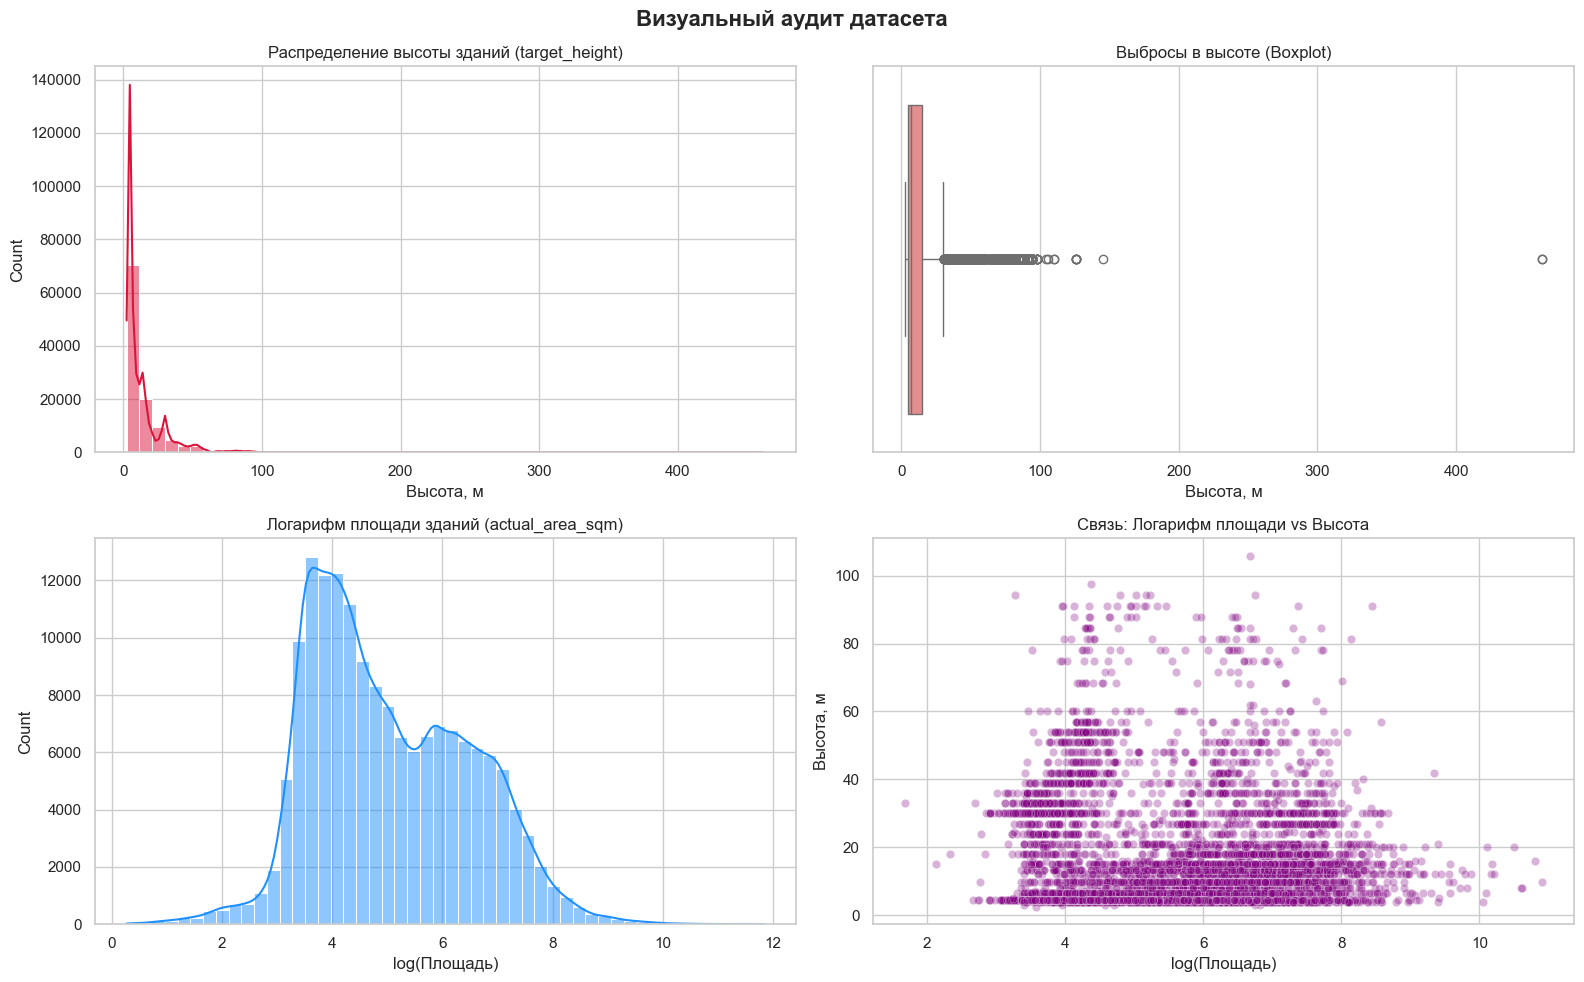

In [42]:
df_eda = pd.read_csv('data/processed/FINAL_DATASET_ABSOLUTE.csv')

has_target = df_eda['target_height'].notna().sum()
no_target = df_eda['target_height'].isna().sum()

print(f"Зданий с известной высотой (Train): {has_target}")
print(f"Зданий без высоты (Test): {no_target}")

print("\nСтатистика по числовым фичам:")
display(df_eda[['target_height', 'actual_area_sqm', 'perimeter_m', 'complex_total_area']].describe().round(2))

# Категории и Доминанты
print("\nТоп (ml_category):")
print(df_eda['ml_category'].value_counts().head(5))

print("\nДоминанты комплексов (is_alpha):")
print(df_eda['is_alpha'].value_counts())


fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Визуальный аудит датасета', fontsize=16, fontweight='bold')

# График 1: Распределение высоты (Таргет)
sns.histplot(df_eda['target_height'].dropna(), bins=50, kde=True, color='crimson', ax=axes[0, 0])
axes[0, 0].set_title('Распределение высоты зданий (target_height)')
axes[0, 0].set_xlabel('Высота, м')

# График 2: Ящик с усами для высоты (поиск жестких выбросов)
sns.boxplot(x=df_eda['target_height'].dropna(), color='lightcoral', ax=axes[0, 1])
axes[0, 1].set_title('Выбросы в высоте (Boxplot)')
axes[0, 1].set_xlabel('Высота, м')

# График 3: Распределение площади - берем логарифм, потому что площади сильно разнятся
sns.histplot(np.log1p(df_eda['actual_area_sqm']), bins=50, kde=True, color='dodgerblue', ax=axes[1, 0])
axes[1, 0].set_title('Логарифм площади зданий (actual_area_sqm)')
axes[1, 0].set_xlabel('log(Площадь)')

# График 4: Площадь vs Высота (Scatter)
# Берем небольшую случайную выборку, чтобы график не тормозил
sample_df = df_eda.dropna(subset=['target_height']).sample(n=min(10000, has_target), random_state=42)
sns.scatterplot(x=np.log1p(sample_df['actual_area_sqm']), y=sample_df['target_height'], 
                alpha=0.3, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Связь: Логарифм площади vs Высота')
axes[1, 1].set_xlabel('log(Площадь)')
axes[1, 1].set_ylabel('Высота, м')

plt.tight_layout()
plt.show()

### Перерассчитываем текущие фичи с учетом нового датасета

In [44]:
df = pd.read_csv('data/processed/FINAL_DATASET_ABSOLUTE.csv', low_memory=False)


gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geometry']), crs="EPSG:4326")

# перевод в метры
gdf_metric = gdf.to_crs(epsg=32636)

# перерасчет площади и периметра куска 
gdf['actual_area_sqm'] = gdf_metric.geometry.area
gdf['perimeter_m'] = gdf_metric.geometry.length

# перерасчет площади комплекса
# Группируем все куски по complex_id и суммируем их новые эталонные площади
gdf['complex_total_area'] = gdf.groupby('complex_id')['actual_area_sqm'].transform('sum')

print(gdf[['id', 'complex_id', 'actual_area_sqm', 'perimeter_m', 'complex_total_area']].head())

gdf.to_csv('data/processed/FINAL_DATASET_ABSOLUTE.csv', index=False)

    id complex_id  actual_area_sqm  perimeter_m  complex_total_area
0  1.0          0        84.990876    59.417369           84.990876
1  2.0          1       114.675350    77.270668          114.675350
2  3.0          2       122.952197   236.330849          122.952197
3  4.0          3        64.048075   107.872806           64.048075
4  5.0          4       170.691163   152.661750          170.691163


## Добавляем новые фичи для ML 
1) coord_x 
                 - центроиды здания (где лежит основная масса)
2) coord_y
3) spatial_cluster (микрорайоны)
4) actual_area_sqm (площадь конкретного куска полигона)
5) perimeter_m
6) compactness (компактность)
7) solidity (сплошность)
8) area_ratio (доля площади куска от площади монолита)
9) log_area (логарифм площади - для выравнивания распределния площади)
10) complex_fragment_count (количество фрагментов из которых созтоит здание)
11) ml_category (очищенная до 'Other')
12) фрактальность периметра (смотрим на количество углов)

In [46]:
df = pd.read_csv('data/processed/FINAL_DATASET_ABSOLUTE.csv', low_memory=False)

gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geometry']), crs="EPSG:4326")

# 1, 2.Координтаы (X, Y)
centroids = gdf.geometry.centroid
gdf['coord_x'] = centroids.x
gdf['coord_y'] = centroids.y


# 3. Микрорайоны (KMeans Clustering) 
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
gdf['spatial_cluster'] = kmeans.fit_predict(gdf[['coord_x', 'coord_y']])

# 4. Компактность = P^2 / S
gdf['compactness'] = (4 * np.pi * gdf['actual_area_sqm']) / (gdf['perimeter_m'] ** 2 + 1e-6)

# 5. Сплошность Solidity
# Временно переводим в метры, чтобы площадь выпуклой оболочки была в честных метрах
convex_hull_area = gdf.to_crs(epsg=32636).geometry.convex_hull.area
gdf['solidity'] = gdf['actual_area_sqm'] / (convex_hull_area + 1e-6)

# 6. Доля площади (Area Ratio)
gdf['area_ratio'] = gdf['actual_area_sqm'] / (gdf['complex_total_area'] + 1e-6)

# 7. Логарифм площади (Log Area)
gdf['log_area'] = np.log1p(gdf['actual_area_sqm'])


# 8. Количество фрагментов здания
gdf['complex_fragment_count'] = gdf.groupby('complex_id')['id'].transform('count')

# 9. ml_category, убираем редкие категории - в другие
if 'ml_category' in gdf.columns:
    category_counts = gdf['ml_category'].value_counts()
    rare_categories = category_counts[category_counts < 50].index
    gdf.loc[gdf['ml_category'].isin(rare_categories), 'ml_category'] = 'Other'
else:
    print("Колонка 'ml_category' не найдена, пропускаем этот шаг.")

# 10. Фрактальность -по количество углов
def count_vertices(geom):
    if geom is None or geom.is_empty or geom.geom_type != 'Polygon':
        return 0
    return len(geom.exterior.coords) - 1

gdf['vertex_count'] = gdf.geometry.apply(count_vertices)

# Для градиентных бустингов геометрия - плохо. Оставляем только чистые цифры и категории
df_ml_ready = pd.DataFrame(gdf.drop(columns=['geometry']))

# Сохраняем итоговый датасет
df_ml_ready.to_csv('data/processed/CATBOOST_READY.csv', index=False)

In [47]:
df_final = pd.read_csv('data/processed/CATBOOST_READY.csv')
lakhta_info = df_final[df_final['target_height'] == 462]
lakhta_info

,id,complex_id,actual_area_sqm,is_alpha,floor_count,target_height,ml_category,perimeter_m,complex_total_area,coord_x,coord_y,spatial_cluster,compactness,solidity,area_ratio,log_area,complex_fragment_count,vertex_count
21835,22196.0,20488,37417.888974,True,87.0,462.0,Неизвестно,1893.359240,37417.888974,30.176511,59.987133,7,0.131167,0.575596,1.000000,10.529931,1,54
22858,23242.0,21652,8533.872620,True,NaN,462.0,Неизвестно,504.888652,8717.927756,30.186311,59.985991,13,0.420693,0.883567,0.978888,9.051916,2,17


удаляем выброс, был найденный по графику на еда

In [48]:

df_final = df_final[df_final['id'] != 23242.0].reset_index(drop=True)
print(f"Осталось записей с высотой 462м: {len(df_final[df_final['target_height'] == 462])}")

# Сохраняем финальный бронебойный датасет
df_final.to_csv('data/processed/CATBOOST_READY.csv', index=False)

Осталось записей с высотой 462м: 1


### Посмотрим на еще похожие аномалии по типу лахты, и просмотрим на карте для оценки правильности данных

In [49]:
df = pd.read_csv('data/processed/FINAL_DATASET_ABSOLUTE.csv')

gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geometry']), crs="EPSG:4326")

# Оставляем только те здания, где есть и высота, и этажи >0, чтобы избежать деления на ноль
gdf_check = gdf.dropna(subset=['target_height', 'floor_count']).copy()
gdf_check = gdf_check[gdf_check['floor_count'] > 0]

# Считаем метры на этаж
gdf_check['m_per_floor'] = gdf_check['target_height'] / gdf_check['floor_count']

# фильтр для аномалий
anomalies = gdf_check[(gdf_check['m_per_floor'] > 6.0) | (gdf_check['m_per_floor'] < 2.2)].copy()

# Сортируем: сверху будут самые дикие выбросы, например, 15 м/этаж
anomalies = anomalies.sort_values(by='m_per_floor', ascending=False)

print(f"Найдено подозрительных зданий: {len(anomalies)} шт.")
# Достаем центр геометрии здания
anomalies['centroid'] = anomalies.geometry.centroid
anomalies['lat'] = anomalies['centroid'].y.round(6)
anomalies['lon'] = anomalies['centroid'].x.round(6)

# Создаем прямую ссылку на спутник Яндекса по координатам
anomalies['yandex_map_link'] = "https://yandex.ru/maps/?pt=" + anomalies['lon'].astype(str) + "," + anomalies['lat'].astype(str) + "&z=18&l=sat"

# Собираем колонки, которые удобно будет смотреть глазами
review_cols = [
    'complex_id', 'target_height', 'floor_count', 'm_per_floor', 
    'is_alpha', 'yandex_map_link'
]

# Проверка, чтобы не упало
review_cols = [c for c in review_cols if c in anomalies.columns]

# Сохраняем в CSV
anomalies[review_cols].to_csv('data/processed/SUSPICIOUS_BUILDINGS.csv', index=False, encoding='utf-8-sig')

Найдено подозрительных зданий: 750 шт.


### Добавим новые фичи через KNN - 5 ближайших соседей  

Features:

* knn_dist_to_closest_m — расстояние до ближайшего соседа (м). Фича определяет тип застройки: отдельно стоящее здание (промзона, ТЦ) или плотная квартальная сетка (исторический центр).

* knn_mean_dist_5_m — среднее расстояние до 5 ближайших зданий. Индикатор плотности района.

* knn_mean_height_5 — средняя историческая высота ближайшего окружения. Задает локальный высотный регламент. Будет генерится для каждого фолда отдельно при обучении модели, так как это наш таргет, чтобы не было утечки данных

* knn_mean_floors_5 — средняя этажность соседей. Помогает восстановить контекст для зданий, у которых в базе ЖКХ отсутствуют данные об этажах.

In [ ]:
df = pd.read_csv('data/processed/CATBOOST_READY.csv')

gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['coord_x'], df['coord_y']),
    crs="EPSG:4326"
)

# Переводим в систему координат Питера, чтобы метры были настоящими
gdf = gdf.to_crs(epsg=32636)

# Достаем честные метрические координаты X и Y в виде numpy массива
coords_metric = np.column_stack((gdf.geometry.x, gdf.geometry.y))

K_NEIGHBORS = 5

# Ищем K+1 соседей, потому что первым соседом всегда будет само здание
nn = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric='euclidean', n_jobs=-1)
nn.fit(coords_metric)

# Получаем расстояния и индексы
distances, indices = nn.kneighbors(coords_metric)

# Отрезаем первый столбец, так как это расстояние здания до самого себя (0 метров)
distances = distances[:, 1:]
indices = indices[:, 1:]

# Добываем оригинальные массивы
target_heights = df['target_height'].values
floor_counts = df['floor_count'].values

# Создаем матрицы: для каждого здания собираем значения его 5 соседей
neighbors_height = target_heights[indices]
neighbors_floor = floor_counts[indices]

# Фича 1: Расстояние до ближайшего здания (в метрах)
# Помогает понять, это плотная застройка или одиноко стоящий ангар
df['knn_dist_to_closest_m'] = distances[:, 0]

# Фича 2: Среднее расстояние до 5 ближайших соседей - показатель плотности
df['knn_mean_dist_5_m'] = np.mean(distances, axis=1)

# Фича 3: Средняя этажность 5 ближайших соседей
df['knn_mean_floors_5'] = np.nanmean(neighbors_floor, axis=1)

for col in ['knn_mean_floors_5']:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)


df.drop(columns=['geometry'], inplace=True, errors='ignore')
df.to_csv('data/processed/CATBOOST_READY_WITH_KNN.csv', index=False)


### Пробуем фиксить те ошибки реестра этажности
Найдено подозрительных зданий: 750 шт.

Логика пространственного фильтра (3 правила):

* Высота этажа < 2.2 м: Физически невозможные здания, куда не поместится человек. Возникают из-за опечаток в кадастре (например, указано 20 этажей вместо 2 при общей высоте 10 метров). Значение floor_count принудительно зануляется (NaN).

* «Фейковые башни» (Высота этажа > 6.0 м И Общая высота > 25.0 м): Специфические промышленные объекты (трубы ТЭЦ, купола церквей, вышки связи), которые по документам числятся как «1 этаж», но имеют высоту 30–100 метров. Оставление таких этажей ломает предиктивную логику модели. Значение floor_count принудительно зануляется (NaN).

* «Честные ангары» (Высота этажа > 6.0 м И Общая высота <= 25.0 м): Исключение из фильтра. Реальные промышленные цеха, логистические склады и торговые центры. Один этаж с потолками 15–20 метров — это норма. Этажность для таких объектов полностью сохраняется.

Преимущества подхода:
Бустинговые модели поддерживают обработку пропущенных значений. Встретив NaN в этажах у высокой трубы, дерево решений просто проигнорирует этот признак и пойдет искать зависимости в других данных: площади основания (actual_area_sqm), тегах (ml_category) и контексте окружения (knn_mean_height_5). Это полностью исключает искажение предсказаний.

In [55]:
INPUT_CSV = "data/processed/CATBOOST_READY_WITH_KNN.csv"
OUTPUT_CSV = "data/processed/CATBOOST_READY_CLEAN_FLOORS.csv"

df = pd.read_csv(INPUT_CSV)
print(f"Всего зданий: {len(df)}")

mask_has_data = df['target_height'].notna() & df['floor_count'].notna() & (df['floor_count'] > 0)

# Временно считаем метры на этаж
df.loc[mask_has_data, 'm_per_floor'] = df.loc[mask_has_data, 'target_height'] / df.loc[mask_has_data, 'floor_count']


# Правило 1: Потолки ниже 2.2м
# Это всегда ошибка кадастра, независимо от общей высоты здания. Человек не влезет в такое здание.
mask_hobbits = mask_has_data & (df['m_per_floor'] < 2.2)

# Правило 2: "Фейковые башни" (Потолки выше 6.0м И общая высота > 25м)
# Если высота <= 25м, это честный промышленный ангар или ТЦ - его не трогаем
mask_fake_towers = mask_has_data & (df['m_per_floor'] > 6.0) & (df['target_height'] > 25.0)

# Объединяем кого идем занулять
bad_floors_mask = mask_hobbits | mask_fake_towers

print(f"Найдено (этаж < 2.2м): {mask_hobbits.sum()} шт.")
print(f"Найдено 'фейковых башен' (>25м и этаж > 6м): {mask_fake_towers.sum()} шт.")
print(f"Честные ангары (<=25м и этаж > 6м), которые мы спасли: { (mask_has_data & (df['m_per_floor'] > 6.0) & (df['target_height'] <= 25.0)).sum() } шт.")

print(f"\nИтого зануляем этажей: {bad_floors_mask.sum()} шт.")


df.loc[bad_floors_mask, 'floor_count'] = np.nan


df.drop(columns=['m_per_floor'], inplace=True)


df.to_csv(OUTPUT_CSV, index=False)

Всего зданий: 164559
Найдено (этаж < 2.2м): 605 шт.
Найдено 'фейковых башен' (>25м и этаж > 6м): 39 шт.
Честные ангары (<=25м и этаж > 6м), которые мы спасли: 106 шт.

Итого зануляем этажей: 644 шт.
